# Cky-ish NLTK chart parsing
This uses cky-like parsing schemas added to 
`nltk.parse.chart` in a local copy of `nltk`. 

I cloned the whole `nltk` and edited `chart.py` in that.  I didn't
get importing `nltk` and loading just the local file to work.


In [9]:
import importlib.util
import sys

In [10]:
sys.path.insert(0, '/local/sys/nltk')

In [11]:
sys.path

['/local/sys/nltk',
 '/local/sys/nltk',
 '/local/sys/nltk',
 '/Users/matsadmin/miniconda3/envs/cl25-312/lib/python312.zip',
 '/Users/matsadmin/miniconda3/envs/cl25-312/lib/python3.12',
 '/Users/matsadmin/miniconda3/envs/cl25-312/lib/python3.12/lib-dynload',
 '',
 '/Users/matsadmin/miniconda3/envs/cl25-312/lib/python3.12/site-packages']

In [12]:
# Import local `nltk`.
import nltk

Look for LexicalSingleEdgeFundamentalRule to make sure the local copy was loaded.
With a CNF grammar, it is used with lexical rhs
`[i,i] A -> * w` licensing [i,i] A -> w *` when `[i,i+1] w` is in
the chart.

In [13]:
print(nltk.parse.chart.LexicalSingleEdgeFundamentalRule)

<class 'nltk.parse.chart.LexicalSingleEdgeFundamentalRule'>


Look forDoubleEdgeFundamentalRule. It is a schema for  `[i,i] A -> *B C` 

licensing `[i,k] A -> B C*` when for some `j`, 

`[i,j] B -> beta *` and `[j,k] C -> gamma *` are in the chart.

In [14]:
print(nltk.parse.chart.DoubleEdgeFundamentalRule)

<class 'nltk.parse.chart.DoubleEdgeFundamentalRule'>


#### Grammar, parser and sentence
The grammar is revised from `nltk.parse.chart.demo_grammar()`.

In [15]:
g = nltk.parse.chart.demo_cnf_grammar()
trace = 2

In [16]:
print(g)

Grammar with 19 productions (start state = S)
    S -> NP VP
    S -> NP Verb
    PP -> WITH NP
    NP -> NP PP
    VP -> VP PP
    VP -> Verb NP
    NP -> Det Noun
    NP -> 'John'
    NP -> 'I'
    Det -> 'the'
    Det -> 'my'
    Det -> 'a'
    Noun -> 'dog'
    Noun -> 'cookie'
    Verb -> 'ate'
    Verb -> 'saw'
    Prep -> 'with'
    WITH -> 'with'
    Prep -> 'under'


In [17]:
p = nltk.parse.chart.SteppingChartParser(g, trace=trace)

In [18]:
sent="I saw John with a dog with my cookie"
tokens = sent.split()
tokens

['I', 'saw', 'John', 'with', 'a', 'dog', 'with', 'my', 'cookie']

### Strategy

In [19]:
leaf_init = nltk.parse.chart.LeafInitRule()
bottom_up_predict = nltk.parse.chart.BottomUpPredictRule()
double_edge = nltk.parse.chart.DoubleEdgeFundamentalRule()
lexical_single_edge = nltk.parse.chart.LexicalSingleEdgeFundamentalRule()

strategy = [leaf_init,
            lexical_single_edge,
            bottom_up_predict,
            double_edge]
strategy

In [20]:
p.set_strategy(strategy)

#### Step the parser

In [21]:
def step(pr,n):
    for j, e in enumerate(pr.step()):
        if j > n or e is None:
            break

In [22]:
p.initialize(tokens)

#### 1. LeafInitRule inserts words

In [23]:
step(p,7)

Leaf Init Rule
|[----]    .    .    .    .    .    .    .    .| [0:1] 'I'
Leaf Init Rule
|.    [----]    .    .    .    .    .    .    .| [1:2] 'saw'
Leaf Init Rule
|.    .    [----]    .    .    .    .    .    .| [2:3] 'John'
Leaf Init Rule
|.    .    .    [----]    .    .    .    .    .| [3:4] 'with'
Leaf Init Rule
|.    .    .    .    [----]    .    .    .    .| [4:5] 'a'
Leaf Init Rule
|.    .    .    .    .    [----]    .    .    .| [5:6] 'dog'
Leaf Init Rule
|.    .    .    .    .    .    [----]    .    .| [6:7] 'with'
Leaf Init Rule
|.    .    .    .    .    .    .    [----]    .| [7:8] 'my'
Leaf Init Rule
|.    .    .    .    .    .    .    .    [----]| [8:9] 'cookie'


In [24]:
print(p.chart().pretty_format())

|. I  .saw .John.with. a  .dog .with. my .cook.|
|[----]    .    .    .    .    .    .    .    .| [0:1] 'I'
|.    [----]    .    .    .    .    .    .    .| [1:2] 'saw'
|.    .    [----]    .    .    .    .    .    .| [2:3] 'John'
|.    .    .    [----]    .    .    .    .    .| [3:4] 'with'
|.    .    .    .    [----]    .    .    .    .| [4:5] 'a'
|.    .    .    .    .    [----]    .    .    .| [5:6] 'dog'
|.    .    .    .    .    .    [----]    .    .| [6:7] 'with'
|.    .    .    .    .    .    .    [----]    .| [7:8] 'my'
|.    .    .    .    .    .    .    .    [----]| [8:9] 'cookie'


#### 2. Bottom Up Predict Rule inserts lexical productions

Insert in [k:k] dotted productions that match the word in [k:k+1]

In [25]:
step(p,9)

Bottom Up Predict Rule
|>    .    .    .    .    .    .    .    .    .| [0:0] NP -> * 'I'
Bottom Up Predict Rule
|.    >    .    .    .    .    .    .    .    .| [1:1] Verb -> * 'saw'
Bottom Up Predict Rule
|.    .    >    .    .    .    .    .    .    .| [2:2] NP -> * 'John'
Bottom Up Predict Rule
|.    .    .    >    .    .    .    .    .    .| [3:3] Prep -> * 'with'
Bottom Up Predict Rule
|.    .    .    >    .    .    .    .    .    .| [3:3] WITH -> * 'with'
Bottom Up Predict Rule
|.    .    .    .    >    .    .    .    .    .| [4:4] Det -> * 'a'
Bottom Up Predict Rule
|.    .    .    .    .    >    .    .    .    .| [5:5] Noun -> * 'dog'
Bottom Up Predict Rule
|.    .    .    .    .    .    >    .    .    .| [6:6] Prep -> * 'with'
Bottom Up Predict Rule
|.    .    .    .    .    .    >    .    .    .| [6:6] WITH -> * 'with'
Bottom Up Predict Rule
|.    .    .    .    .    .    .    >    .    .| [7:7] Det -> * 'my'
Bottom Up Predict Rule
|.    .    .    .    .    .    .    .    > 

In [26]:
print(p.chart().pretty_format())

|. I  .saw .John.with. a  .dog .with. my .cook.|
|>    .    .    .    .    .    .    .    .    .| [0:0] NP -> * 'I'
|.    >    .    .    .    .    .    .    .    .| [1:1] Verb -> * 'saw'
|.    .    >    .    .    .    .    .    .    .| [2:2] NP -> * 'John'
|.    .    .    >    .    .    .    .    .    .| [3:3] Prep -> * 'with'
|.    .    .    >    .    .    .    .    .    .| [3:3] WITH -> * 'with'
|.    .    .    .    >    .    .    .    .    .| [4:4] Det -> * 'a'
|.    .    .    .    .    >    .    .    .    .| [5:5] Noun -> * 'dog'
|.    .    .    .    .    .    >    .    .    .| [6:6] Prep -> * 'with'
|.    .    .    .    .    .    >    .    .    .| [6:6] WITH -> * 'with'
|.    .    .    .    .    .    .    >    .    .| [7:7] Det -> * 'my'
|.    .    .    .    .    .    .    .    >    .| [8:8] Noun -> * 'cookie'
|[----]    .    .    .    .    .    .    .    .| [0:1] 'I'
|.    [----]    .    .    .    .    .    .    .| [1:2] 'saw'
|.    .    [----]    .    .    .    .    .    .| [2:3

#### 3. Lexical Single Edge Fundamental Rule 
... advances the dot for lexical span productions (edges). It is a new
schema that is a restricted version of `SingleEdgeFundamentalRule`.
It applies only when the rhs is a single terminal (string).

In [27]:
step(p,7)

Lexical Single Edge Fundamental Rule
|[----]    .    .    .    .    .    .    .    .| [0:1] NP -> 'I' *
Lexical Single Edge Fundamental Rule
|.    [----]    .    .    .    .    .    .    .| [1:2] Verb -> 'saw' *
Lexical Single Edge Fundamental Rule
|.    .    [----]    .    .    .    .    .    .| [2:3] NP -> 'John' *
Lexical Single Edge Fundamental Rule
|.    .    .    [----]    .    .    .    .    .| [3:4] Prep -> 'with' *
Lexical Single Edge Fundamental Rule
|.    .    .    [----]    .    .    .    .    .| [3:4] WITH -> 'with' *
Lexical Single Edge Fundamental Rule
|.    .    .    .    [----]    .    .    .    .| [4:5] Det -> 'a' *
Lexical Single Edge Fundamental Rule
|.    .    .    .    .    [----]    .    .    .| [5:6] Noun -> 'dog' *
Lexical Single Edge Fundamental Rule
|.    .    .    .    .    .    [----]    .    .| [6:7] Prep -> 'with' *
Lexical Single Edge Fundamental Rule
|.    .    .    .    .    .    [----]    .    .| [6:7] WITH -> 'with' *


#### 4. BottomUpPredictRule
inserts producitions `A -> B ...` in `[k,k]` matching a `B` in `[k,_]`.

In [20]:
step(p,6)

Lexical Single Edge Fundamental Rule
|.    .    .    .    .    .    .    [----]    .| [7:8] Det -> 'my' *
Lexical Single Edge Fundamental Rule
|.    .    .    .    .    .    .    .    [----]| [8:9] Noun -> 'cookie' *
Bottom Up Predict Rule
|>    .    .    .    .    .    .    .    .    .| [0:0] S  -> * NP VP
Bottom Up Predict Rule
|>    .    .    .    .    .    .    .    .    .| [0:0] S  -> * NP Verb
Bottom Up Predict Rule
|>    .    .    .    .    .    .    .    .    .| [0:0] NP -> * NP PP
Bottom Up Predict Rule
|.    >    .    .    .    .    .    .    .    .| [1:1] VP -> * Verb NP
Bottom Up Predict Rule
|.    .    >    .    .    .    .    .    .    .| [2:2] S  -> * NP VP
Bottom Up Predict Rule
|.    .    >    .    .    .    .    .    .    .| [2:2] S  -> * NP Verb


In [21]:
# Gave an error
# print(p.chart().pretty_format())

#### 5. Advance dots
`DoubleEdgeFundamentalRule` advances the dot 
over a pair of complete edges in one step.  

In [28]:
step(p,1)

Lexical Single Edge Fundamental Rule
|.    .    .    .    .    .    .    [----]    .| [7:8] Det -> 'my' *
Lexical Single Edge Fundamental Rule
|.    .    .    .    .    .    .    .    [----]| [8:9] Noun -> 'cookie' *
Bottom Up Predict Rule
|>    .    .    .    .    .    .    .    .    .| [0:0] S  -> * NP VP


In [29]:
step(p,0)

Bottom Up Predict Rule
|>    .    .    .    .    .    .    .    .    .| [0:0] S  -> * NP Verb
Bottom Up Predict Rule
|>    .    .    .    .    .    .    .    .    .| [0:0] NP -> * NP PP


#### 7. Further cycles of `BottomUpPredictRule` and `DoubleEdgeFundamentalRule`

In [30]:
step(p,8)

Bottom Up Predict Rule
|.    >    .    .    .    .    .    .    .    .| [1:1] VP -> * Verb NP
Bottom Up Predict Rule
|.    .    >    .    .    .    .    .    .    .| [2:2] S  -> * NP VP
Bottom Up Predict Rule
|.    .    >    .    .    .    .    .    .    .| [2:2] S  -> * NP Verb
Bottom Up Predict Rule
|.    .    >    .    .    .    .    .    .    .| [2:2] NP -> * NP PP
Bottom Up Predict Rule
|.    .    .    >    .    .    .    .    .    .| [3:3] PP -> * WITH NP
Bottom Up Predict Rule
|.    .    .    .    >    .    .    .    .    .| [4:4] NP -> * Det Noun
Bottom Up Predict Rule
|.    .    .    .    .    .    >    .    .    .| [6:6] PP -> * WITH NP
Bottom Up Predict Rule
|.    .    .    .    .    .    .    >    .    .| [7:7] NP -> * Det Noun
Double Edge Fundamental Rule
|[---------]    .    .    .    .    .    .    .| [0:2] S  -> NP Verb *
Double Edge Fundamental Rule
|.    [---------]    .    .    .    .    .    .| [1:3] VP -> Verb NP *


In [31]:
step(p,8)

Bottom Up Predict Rule
|.    >    .    .    .    .    .    .    .    .| [1:1] VP -> * VP PP
Double Edge Fundamental Rule
|[--------------]    .    .    .    .    .    .| [0:3] S  -> NP VP *
Double Edge Fundamental Rule
|.    .    .    .    [---------]    .    .    .| [4:6] NP -> Det Noun *
Double Edge Fundamental Rule
|.    .    .    .    .    .    .    [---------]| [7:9] NP -> Det Noun *
Bottom Up Predict Rule
|.    .    .    .    >    .    .    .    .    .| [4:4] S  -> * NP VP
Bottom Up Predict Rule
|.    .    .    .    >    .    .    .    .    .| [4:4] S  -> * NP Verb
Bottom Up Predict Rule
|.    .    .    .    >    .    .    .    .    .| [4:4] NP -> * NP PP
Bottom Up Predict Rule
|.    .    .    .    .    .    .    >    .    .| [7:7] S  -> * NP VP
Bottom Up Predict Rule
|.    .    .    .    .    .    .    >    .    .| [7:7] S  -> * NP Verb
Bottom Up Predict Rule
|.    .    .    .    .    .    .    >    .    .| [7:7] NP -> * NP PP


In [32]:
step(p,8)

Double Edge Fundamental Rule
|.    .    .    [--------------]    .    .    .| [3:6] PP -> WITH NP *
Double Edge Fundamental Rule
|.    .    .    .    .    .    [--------------]| [6:9] PP -> WITH NP *
Double Edge Fundamental Rule
|.    [------------------------]    .    .    .| [1:6] VP -> VP PP *
Double Edge Fundamental Rule
|.    [---------------------------------------]| [1:9] VP -> VP PP *
Double Edge Fundamental Rule
|.    .    .    .    [------------------------]| [4:9] NP -> NP PP *
Double Edge Fundamental Rule
|[-----------------------------]    .    .    .| [0:6] S  -> NP VP *
Double Edge Fundamental Rule
|[============================================]| [0:9] S  -> NP VP *
Double Edge Fundamental Rule
|.    .    [-------------------]    .    .    .| [2:6] NP -> NP PP *
Double Edge Fundamental Rule
|.    .    [----------------------------------]| [2:9] NP -> NP PP *
Double Edge Fundamental Rule
|.    .    .    [-----------------------------]| [3:9] PP -> WITH NP *


In [33]:
step(p,8)

Double Edge Fundamental Rule
|.    [------------------------]    .    .    .| [1:6] VP -> Verb NP *
Double Edge Fundamental Rule
|.    [---------------------------------------]| [1:9] VP -> Verb NP *
Double Edge Fundamental Rule
|.    .    [----------------------------------]| [2:9] NP -> NP PP *
Double Edge Fundamental Rule
|.    [---------------------------------------]| [1:9] VP -> VP PP *
Double Edge Fundamental Rule
|.    [---------------------------------------]| [1:9] VP -> VP PP *
Double Edge Fundamental Rule
|[-----------------------------]    .    .    .| [0:6] S  -> NP VP *
Double Edge Fundamental Rule
|[============================================]| [0:9] S  -> NP VP *


#### No more steps to do

In [34]:
step(p,1)

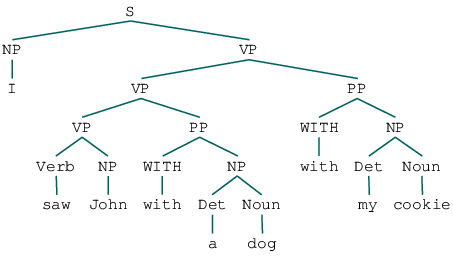

In [35]:
trees = p.parses()
next(trees)

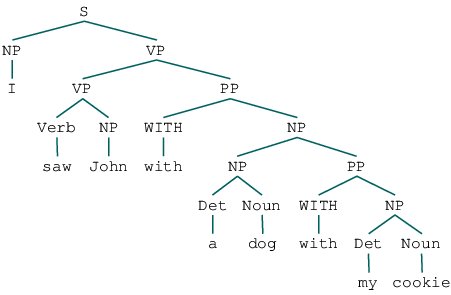

In [36]:
next(trees)

So this is working!  The trees look better than they used to.

## Workspace

In [30]:
es = p.chart().edges()

In [33]:
es[10]

[Edge: [1:1] Verb -> * 'saw']

In [38]:
isinstance(es[10].rhs()[0],str)

True

In [40]:
len(es[10].rhs())

1

In [31]:
p.chart().leaves()

('I', 'saw', 'John', 'with', 'a', 'dog', 'with', 'my', 'cookie')

In [32]:
p.chart().leaf(2)

'John'

In [29]:
help(p.chart())

Help on Chart in module nltk.parse.chart object:

class Chart(builtins.object)
 |  Chart(tokens)
 |
 |  A blackboard for hypotheses about the syntactic constituents of a
 |  sentence.  A chart contains a set of edges, and each edge encodes
 |  a single hypothesis about the structure of some portion of the
 |  sentence.
 |
 |  The ``select`` method can be used to select a specific collection
 |  of edges.  For example ``chart.select(is_complete=True, start=0)``
 |  yields all complete edges whose start indices are 0.  To ensure
 |  the efficiency of these selection operations, ``Chart`` dynamically
 |  creates and maintains an index for each set of attributes that
 |  have been selected on.
 |
 |  In order to reconstruct the trees that are represented by an edge,
 |  the chart associates each edge with a set of child pointer lists.
 |  A child pointer list is a list of the edges that license an
 |  edge's right-hand side.
 |
 |  :ivar _tokens: The sentence that the chart covers.
 |  :iv

## Define a rule

#### Define a duplicate to check adding a rule
This copies the definition of `SingleEdgeFundamentalRule`.

In [155]:
import nltk.parse.chart

In [167]:
class LoneEdgeFundamentalRule(nltk.parse.chart.FundamentalRule):
    NUM_EDGES = 1
    def apply(self, chart, grammar, edge):
        if edge.is_incomplete():
            yield from self._apply_incomplete(chart, grammar, edge)
        else:
            yield from self._apply_complete(chart, grammar, edge)
    def _apply_complete(self, chart, grammar, right_edge):
        for left_edge in chart.select(
            end=right_edge.start(), is_complete=False, nextsym=right_edge.lhs()
        ):
            new_edge = left_edge.move_dot_forward(right_edge.end())
            if chart.insert_with_backpointer(new_edge, left_edge, right_edge):
                yield new_edge
    def _apply_incomplete(self, chart, grammar, left_edge):
        for right_edge in chart.select(
            start=left_edge.end(), is_complete=True, lhs=left_edge.nextsym()
        ):
            new_edge = left_edge.move_dot_forward(right_edge.end())
            if chart.insert_with_backpointer(new_edge, left_edge, right_edge):
                yield new_edge



In [168]:
nltk.parse.chart.LoneEdgeFundamentalRule = LoneEdgeFundamentalRule

In [169]:
strategy

In [170]:
strategy2 = [strategy[0],strategy[1],nltk.parse.chart.LoneEdgeFundamentalRule]

In [171]:
strategy2

 __main__.LoneEdgeFundamentalRule]

In [172]:
p.set_strategy(strategy2)
p.initialize(tokens)

In [175]:
help(strategy[0])

Help on LeafInitRule in module nltk.parse.chart object:

class LeafInitRule(AbstractChartRule)
 |  Method resolution order:
 |      LeafInitRule
 |      AbstractChartRule
 |      ChartRuleI
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  apply(self, chart, grammar)
 |      Return a generator that will add edges licensed by this rule
 |      and the given edges to the chart, one at a time.  Each
 |      time the generator is resumed, it will either add a new
 |      edge and yield that edge; or return.
 |
 |      :type edges: list(EdgeI)
 |      :param edges: A set of existing edges.  The number of edges
 |          that should be passed to ``apply()`` is specified by the
 |          ``NUM_EDGES`` class variable.
 |      :rtype: iter(EdgeI)
 |
 |  ----------------------------------------------------------------------
 |  Data and other attributes defined here:
 |
 |  NUM_EDGES = 0
 |
 |  ----------------------------------------------------------------------
 |  Methods inher

In [174]:
step(p,12)

Bottom Up Predict Rule
|.    .    .    .    >    .    .    .    .    .| [4:4] Det -> * 'a'
Bottom Up Predict Rule
|.    .    .    .    .    >    .    .    .    .| [5:5] Noun -> * 'dog'
Bottom Up Predict Rule
|.    .    .    .    .    .    >    .    .    .| [6:6] PP -> * 'with' NP
Bottom Up Predict Rule
|.    .    .    .    .    .    >    .    .    .| [6:6] Prep -> * 'with'
Bottom Up Predict Rule
|.    .    .    .    .    .    .    >    .    .| [7:7] Det -> * 'my'
Bottom Up Predict Rule
|.    .    .    .    .    .    .    .    >    .| [8:8] Noun -> * 'cookie'


TypeError: AbstractChartRule.apply_everywhere() missing 1 required positional argument: 'grammar'